# OpenRouter catalogue: models, free tier and providers

An exploration of OpenRouter's **public, no-key metadata**: the model catalogue, the free models, and the providers that serve each model.

Data comes from one snapshot made by `fetch.py` (see the README) and is flattened by `tables.py`. To refresh: `python fetch.py`, then re-run this notebook. It always loads the latest snapshot.

**Conventions**
- Prices are USD per million tokens. The *blended* price weights input:output 3:1, the usual way to give one number per model.
- *Unique models* leaves out `:batch` / `:free` variants, `~…-latest` aliases and OpenRouter's routers, so each underlying model counts once.
- *Open weights* means the listing links a Hugging Face repo. That's a proxy, and it can miss models whose weights are published elsewhere.
- `created` is when the model was **added to OpenRouter**, not its original release date.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import viz
from viz import BLUE, ORANGE, AQUA, NEUTRAL, TEXT, TEXT_2, MUTED
from tables import load_tables

viz.setup()
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)

snap = load_tables()
models, endpoints, providers = snap.models, snap.endpoints, snap.providers
primary = models[models.is_primary].copy()
paid = primary[(primary.price_in > 0) | (primary.price_out > 0)]
# Provider endpoints for the unique models (excludes :free / :batch variant endpoints)
ep = endpoints[endpoints.variant.isna() & endpoints.base_id.isin(primary.id)].copy()

usd = FuncFormatter(lambda v, _: f"${v:,.2f}" if v < 1 else f"${v:,.0f}")
print(f"Snapshot: {snap.date}")

Snapshot: 2026-09-30


In [2]:
summary = pd.Series({
    "Catalogue listings": len(models),
    "Unique models": len(primary),
    "  with open weights (HF link)": int(primary.open_weights.sum()),
    "  with an Artificial Analysis intelligence score": int(primary.aa_intelligence.notna().sum()),
    "Free listings (price 0)": int(models.is_free.sum()),
    ":batch variants": int((models.variant == "batch").sum()),
    "Aliases (~…-latest)": int(models.is_alias.sum()),
    "Routers": int(models.is_router.sum()),
    "Publishers (author prefix)": primary.author.nunique(),
    "Providers listed": len(providers),
    "Providers serving at least one model": endpoints.provider.nunique(),
    "Provider endpoints (unique models)": len(ep),
}, name="count")
summary.to_frame()

,count
Catalogue listings,464
Unique models,348
with open weights (HF link),156
with an Artificial Analysis intelligence score,96
Free listings (price 0),19
:batch variants,75
Aliases (~…-latest),18
Routers,7
Publishers (author prefix),53
Providers listed,112


## 1. The catalogue

### 1.1 How much do models cost?

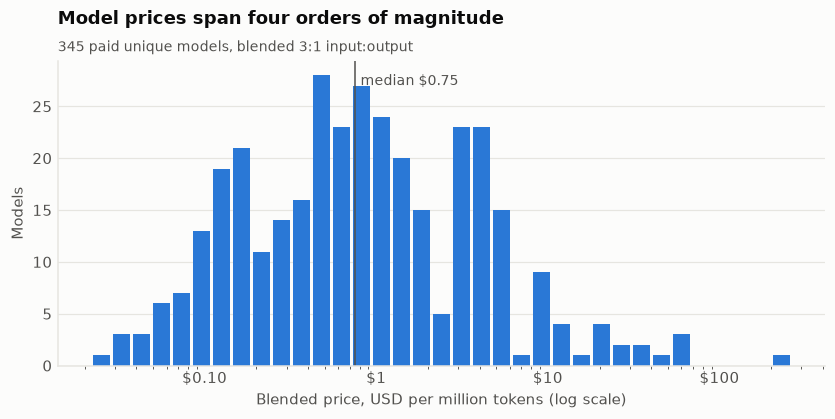

,price_in,price_out,price_blended
p10,0.07,0.2,0.11
p25,0.15,0.5,0.26
median,0.42,1.8,0.75
p75,1.40,6.0,3.00
p90,3.00,14.6,6.00
max,150.00,600.0,262.50


In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.logspace(np.log10(paid.price_blended.min()), np.log10(paid.price_blended.max()), 36)
ax.hist(paid.price_blended, bins=bins, color=BLUE, rwidth=0.85)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(usd)
med = paid.price_blended.median()
ax.axvline(med, color=TEXT_2, lw=1)
ax.text(med * 1.08, ax.get_ylim()[1] * 0.92, f"median ${med:,.2f}", color=TEXT_2, fontsize=9)
ax.set_xlabel("Blended price, USD per million tokens (log scale)")
ax.set_ylabel("Models")
ax.grid(axis="x", visible=False)
viz.title(ax, "Model prices span four orders of magnitude",
          f"{len(paid)} paid unique models, blended 3:1 input:output")
plt.show()

q = paid[["price_in", "price_out", "price_blended"]].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
q.index = ["p10", "p25", "median", "p75", "p90", "max"]
q.round(2)

### 1.2 Price against capability

This uses the Artificial Analysis intelligence index that OpenRouter includes in `benchmarks`, which only covers some models. The **frontier** line joins each model that scores higher than every cheaper model. Those are the best-value choices at each price point.

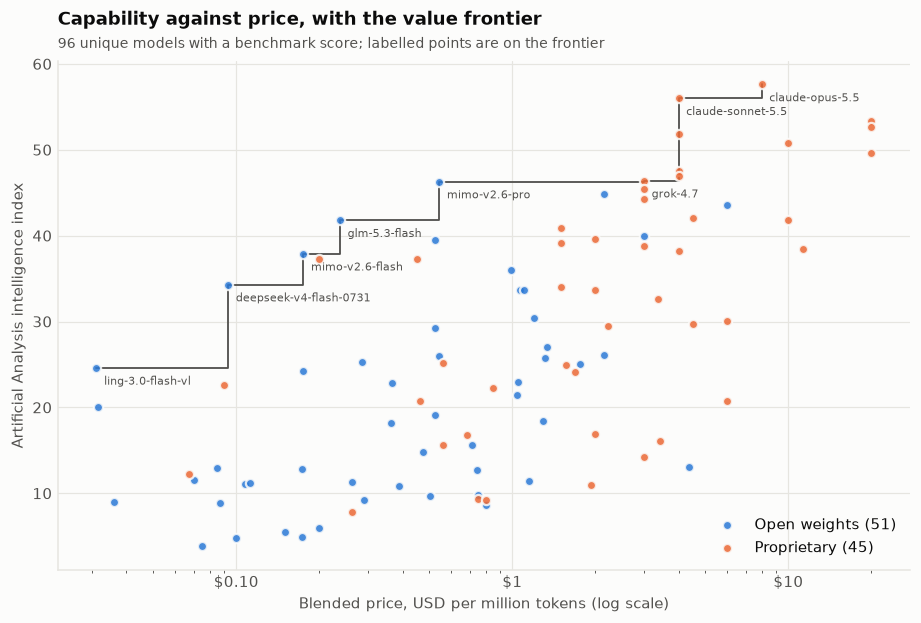

,id,aa_intelligence,price_in,price_out,price_blended,open_weights,n_providers
0,anthropic/claude-opus-5.5,57.6,4.00,20.00,8.00,False,5
1,anthropic/claude-sonnet-5.5,56.0,2.00,10.00,4.00,False,5
2,x-ai/grok-4.7,46.4,2.00,6.00,3.00,False,1
3,xiaomi/mimo-v2.6-pro,46.3,0.44,0.87,0.54,True,3
4,z-ai/glm-5.3-flash,41.8,0.15,0.50,0.24,True,31
5,xiaomi/mimo-v2.6-flash,37.9,0.14,0.28,0.18,True,5
6,deepseek/deepseek-v4-flash-0731,34.3,0.02,0.32,0.09,True,28
7,inclusionai/ling-3.0-flash-vl,24.6,0.02,0.06,0.03,True,2


In [4]:
s = primary.dropna(subset=["aa_intelligence"])
# Sort by price, best score first within a price tie, so tied-but-worse models are not on the frontier.
s = s[s.price_blended > 0].sort_values(["price_blended", "aa_intelligence"], ascending=[True, False])
frontier = s[s.aa_intelligence > s.aa_intelligence.cummax().shift(fill_value=-1)]

fig, ax = plt.subplots(figsize=(10, 6))
for flag, color, label in [(True, BLUE, "Open weights"), (False, ORANGE, "Proprietary")]:
    d = s[s.open_weights == flag]
    ax.scatter(d.price_blended, d.aa_intelligence, s=36, color=color, alpha=0.85,
               edgecolor=viz.SURFACE, linewidth=1.5, label=f"{label} ({len(d)})", zorder=3)
ax.step(frontier.price_blended, frontier.aa_intelligence, where="post", color=TEXT_2, lw=1.2, zorder=2)
for _, r in frontier.iterrows():
    ax.annotate(r["id"].split("/")[1], (r.price_blended, r.aa_intelligence), xytext=(5, -11),
                textcoords="offset points", fontsize=7.5, color=TEXT_2)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(usd)
ax.set_xlabel("Blended price, USD per million tokens (log scale)")
ax.set_ylabel("Artificial Analysis intelligence index")
ax.legend(loc="lower right")
viz.title(ax, "Capability against price, with the value frontier",
          f"{len(s)} unique models with a benchmark score; labelled points are on the frontier")
plt.show()

frontier[["id", "aa_intelligence", "price_in", "price_out", "price_blended", "open_weights", "n_providers"]] \
    .sort_values("aa_intelligence", ascending=False).round(2).reset_index(drop=True)

### 1.3 Context windows

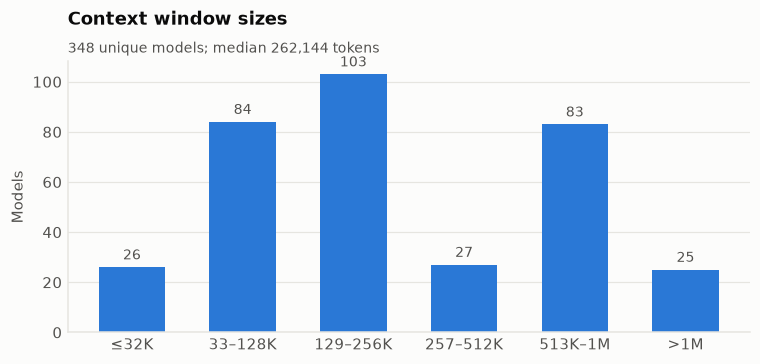

In [5]:
edges = [0, 32_768, 131_072, 262_144, 524_288, 1_048_576, np.inf]
names = ["≤32K", "33–128K", "129–256K", "257–512K", "513K–1M", ">1M"]
ctx = pd.cut(primary.context_length, bins=edges, labels=names, right=True).value_counts().reindex(names)

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(ctx.index, ctx.values, width=0.6, color=BLUE)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, color=TEXT_2, fontsize=9)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Models")
viz.title(ax, "Context window sizes", f"{len(primary)} unique models; median {primary.context_length.median():,.0f} tokens")
plt.show()

### 1.4 What models can do

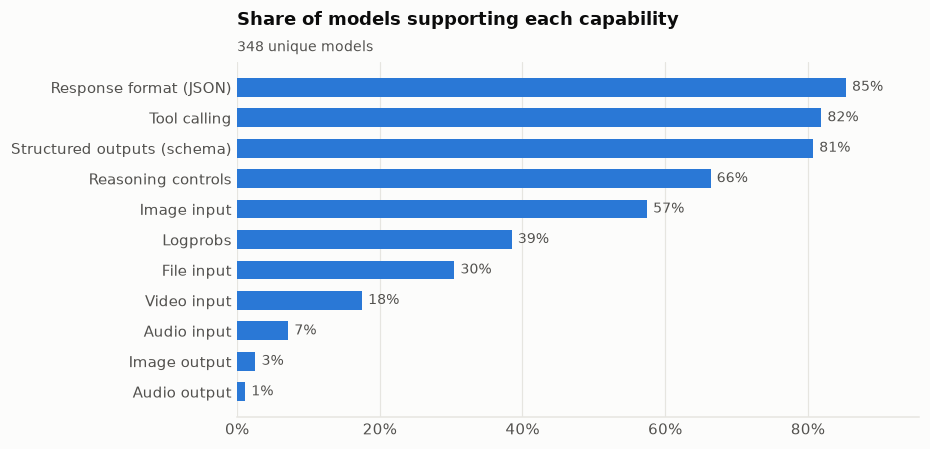

In [6]:
caps = {
    "Tool calling": "supports_tools",
    "Response format (JSON)": "supports_response_format",
    "Structured outputs (schema)": "supports_structured_outputs",
    "Reasoning controls": "supports_reasoning",
    "Image input": "input_image",
    "File input": "input_file",
    "Video input": "input_video",
    "Audio input": "input_audio",
    "Logprobs": "supports_logprobs",
    "Image output": "output_image",
    "Audio output": "output_audio",
}
share = pd.Series({k: primary[c].mean() * 100 for k, c in caps.items()}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.2))
viz.hbar(ax, share.index, share.values, fmt="{:.0f}%")
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
viz.title(ax, "Share of models supporting each capability", f"{len(primary)} unique models")
plt.show()

### 1.5 Who publishes the models?

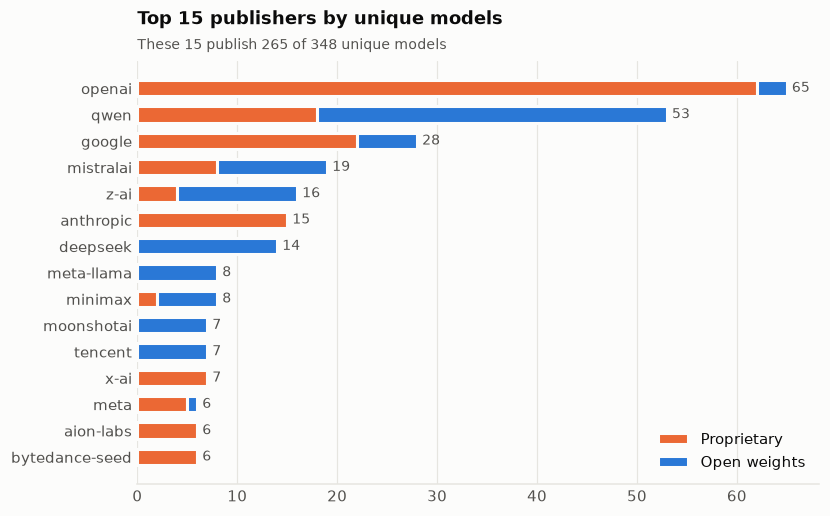

In [7]:
top = primary.groupby("author").agg(open=("open_weights", "sum"), total=("id", "size"))
top["proprietary"] = top.total - top.open
top = top.sort_values("total", ascending=False).head(15)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.proprietary, height=0.62, color=ORANGE, label="Proprietary", edgecolor=viz.SURFACE, linewidth=2)
ax.barh(top.index, top.open, left=top.proprietary, height=0.62, color=BLUE, label="Open weights", edgecolor=viz.SURFACE, linewidth=2)
for y, t in enumerate(top.total):
    ax.text(t + 0.5, y, f"{t}", va="center", fontsize=9, color=TEXT_2)
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.legend(loc="lower right")
viz.title(ax, "Top 15 publishers by unique models",
          f"These 15 publish {top.total.sum()} of {len(primary)} unique models")
plt.show()

### 1.6 How fast are models being added?

This counts models by the month they were added to OpenRouter. The current month is only partly complete.

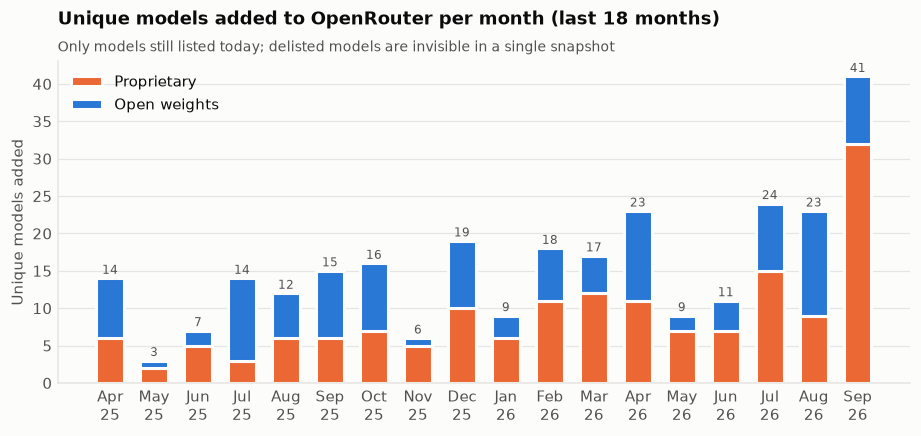

In [8]:
added = primary.assign(month=primary.created.dt.tz_localize(None).dt.to_period("M"))
by_month = added.groupby(["month", "open_weights"]).size().unstack(fill_value=0)
by_month = by_month.reindex(pd.period_range(by_month.index.max() - 17, by_month.index.max(), freq="M"), fill_value=0)
by_month = by_month.reindex(columns=[False, True], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 3.8))
x = by_month.index.strftime("%b\n%y")
ax.bar(x, by_month[False], width=0.62, color=ORANGE, label="Proprietary", edgecolor=viz.SURFACE, linewidth=2)
ax.bar(x, by_month[True], bottom=by_month[False], width=0.62, color=BLUE, label="Open weights", edgecolor=viz.SURFACE, linewidth=2)
for i, t in enumerate(by_month.sum(axis=1)):
    ax.text(i, t + 0.6, str(t), ha="center", fontsize=8, color=TEXT_2)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Unique models added")
ax.legend(loc="upper left")
viz.title(ax, "Unique models added to OpenRouter per month (last 18 months)",
          "Only models still listed today; delisted models are invisible in a single snapshot")
plt.show()

### 1.7 Models scheduled for retirement

In [9]:
retiring = models[models.expiration_date.notna()][["id", "expiration_date", "price_blended", "n_providers"]]
retiring.sort_values("expiration_date").round(2).reset_index(drop=True)

,id,expiration_date,price_blended,n_providers
0,minimax/minimax-m2.1,2026-10-08,0.52,2
1,baidu/ernie-4.5-vl-424b-a47b,2026-10-08,0.63,1
2,qwen/qwen3.6-max-preview,2026-10-09,2.31,1
3,qwen/qwen3-max-thinking,2026-10-09,1.56,1
4,qwen/qwen3-vl-32b-instruct,2026-10-09,0.18,1
5,qwen/qwen3-vl-8b-thinking,2026-10-09,0.66,1
6,qwen/qwen3-vl-8b-instruct,2026-10-09,0.20,2
7,qwen/qwen3-vl-30b-a3b-thinking,2026-10-09,0.75,2
8,qwen/qwen3-vl-235b-a22b-thinking,2026-10-09,1.30,2
9,qwen/qwen3-max,2026-10-09,1.56,1


## 2. The free models

Free listings cost nothing per token but are rate-limited, and are usually a `:free` variant of a paid model. What do you give up compared with the paid version?

In [10]:
free = models[models.is_free & ~models.is_router].copy()
paid_sib = models[models.variant.isna() & ~models.is_router].set_index("id")

def ep_max(ids, col):
    return endpoints[endpoints.model_id.isin(ids)].groupby("model_id")[col].max()

free["free_ctx"] = free.id.map(ep_max(free.id, "context_length"))
free["free_max_out"] = free.id.map(ep_max(free.id, "max_completion_tokens"))
free["free_host"] = free.id.map(endpoints.groupby("model_id").provider.first())
has_sib = free.variant.eq("free") & free.base_id.isin(paid_sib.index)
free["paid_version"] = has_sib
free["paid_price_blended"] = free.base_id.map(paid_sib.price_blended).where(has_sib)
free["paid_providers"] = free.base_id.map(paid_sib.n_providers).where(has_sib)
free["paid_ctx"] = free.base_id.map(ep_max(paid_sib.index, "context_length")).where(has_sib)
free["paid_max_out"] = free.base_id.map(ep_max(paid_sib.index, "max_completion_tokens")).where(has_sib)
free["aa_intelligence"] = free.aa_intelligence.fillna(free.base_id.map(paid_sib.aa_intelligence))
free["days_listed"] = (pd.Timestamp(snap.date, tz="UTC") - free.created).dt.days

free_table = free[["id", "modality", "supports_tools", "aa_intelligence", "free_ctx", "paid_ctx",
                   "free_max_out", "paid_max_out", "paid_price_blended", "paid_providers", "free_host", "days_listed"]]
free_table.sort_values("days_listed").reset_index(drop=True)

,id,modality,supports_tools,aa_intelligence,free_ctx,paid_ctx,free_max_out,paid_max_out,paid_price_blended,paid_providers,free_host,days_listed
0,stealth/space-bunny-alpha,text+image+video->text,True,NaN,1000000,NaN,524288,NaN,NaN,NaN,Stealth,6
1,inclusionai/ling-3.0-flash-sante:free,text->text,True,NaN,262144,NaN,32768,NaN,NaN,NaN,Novita,25
2,qwen/qwen3.8-27b:free,text+image+video->text,True,33.7,262144,1000000.0,235929,262144.0,1.065000,16.0,ModelRun,46
3,dots-studio/dots-3-note-preview:free,text+image->text,True,NaN,512000,NaN,460800,NaN,NaN,NaN,AtlasCloud,46
4,liquid/lfm-2.5-2.6b:free,text->text,True,NaN,65536,NaN,8192,NaN,NaN,NaN,Liquid,49
5,nvidia/nemotron-3.5-lightning:free,text->text,True,12.9,1000000,262144.0,65536,235929.0,0.085000,5.0,Nvidia,49
6,thinkingmachines/inkling-small:free,text+image+audio->text,True,NaN,1048576,524288.0,262144,262144.0,0.637500,1.0,Thinking Machines,61
7,poolside/laguna-s-2.1:free,text->text,True,NaN,262144,1048576.0,32768,131072.0,0.112500,1.0,Poolside,70
8,thinkingmachines/inkling:free,text+image+audio->text,True,25.0,1048576,524288.0,262144,471859.0,1.762500,2.0,Thinking Machines,74
9,poolside/laguna-xs-2.1:free,text->text,True,NaN,262144,262144.0,32768,32768.0,0.075000,1.0,Poolside,89


### 2.1 Free limits compared with the paid version

For each free variant, this compares the free endpoint's context window and output limit with the largest offered by any paid provider of the same model.

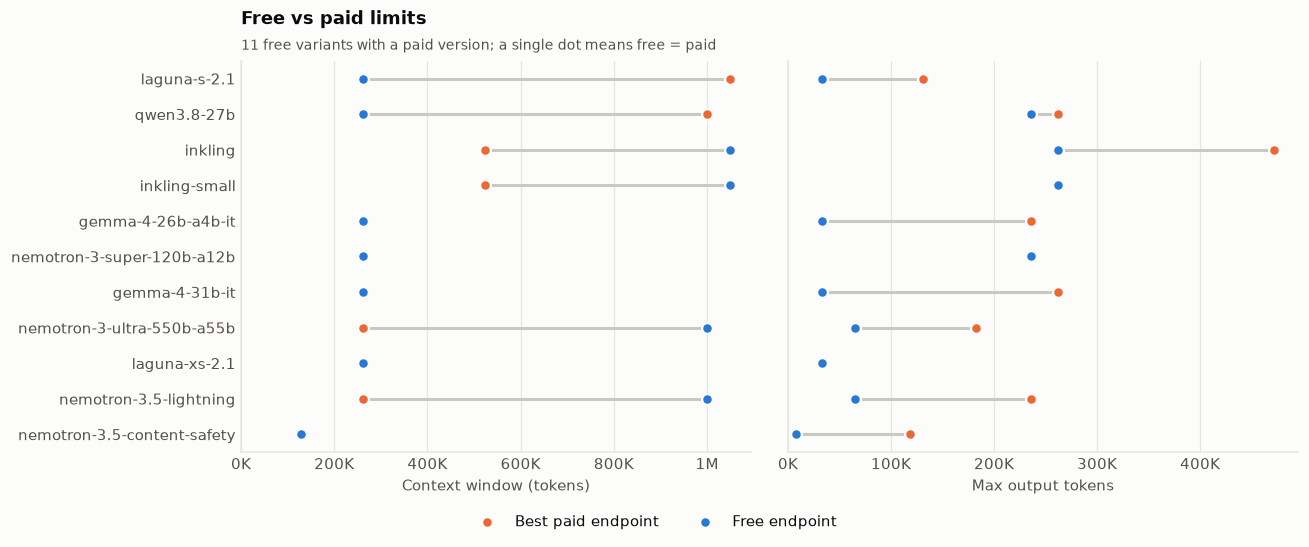

Free context window is smaller than paid for 3 of 11 models (median ratio 1.00)
Free max output is smaller than paid for 8 of 11 models with both values (median ratio 0.36)


In [11]:
cmp_ = free[free.paid_version].sort_values("paid_ctx")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (fcol, pcol, label) in zip(axes, [("free_ctx", "paid_ctx", "Context window (tokens)"),
                                          ("free_max_out", "paid_max_out", "Max output tokens")]):
    y = np.arange(len(cmp_))
    ax.hlines(y, cmp_[fcol], cmp_[pcol], color=NEUTRAL, lw=2, zorder=1)
    ax.scatter(cmp_[pcol], y, s=50, color=ORANGE, edgecolor=viz.SURFACE, linewidth=1.5, zorder=3, label="Best paid endpoint")
    ax.scatter(cmp_[fcol], y, s=50, color=BLUE, edgecolor=viz.SURFACE, linewidth=1.5, zorder=4, label="Free endpoint")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:,.0f}K" if v < 1e6 else f"{v/1e6:g}M"))
    ax.set_xlim(0, None)
    ax.set_xlabel(label)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(np.arange(len(cmp_)), cmp_.id.str.replace(":free", "").str.split("/").str[1])
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0))
viz.title(axes[0], "Free vs paid limits", f"{len(cmp_)} free variants with a paid version; a single dot means free = paid")
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

cut = cmp_.assign(ctx_ratio=cmp_.free_ctx / cmp_.paid_ctx, out_ratio=cmp_.free_max_out / cmp_.paid_max_out)
print(f"Free context window is smaller than paid for {(cut.ctx_ratio < 1).sum()} of {len(cut)} models "
      f"(median ratio {cut.ctx_ratio.median():.2f})")
print(f"Free max output is smaller than paid for {(cut.out_ratio < 1).sum()} of {cut.out_ratio.notna().sum()} models with both values "
      f"(median ratio {cut.out_ratio.median():.2f})")

### 2.2 Who hosts the free endpoints, and what's missing compared with paid models

Free endpoints by host:
provider
Nvidia               5
Google AI Studio     4
Thinking Machines    2
Poolside             2
Stealth              1
Novita               1
ModelRun             1
AtlasCloud           1
Liquid               1
Cohere               1


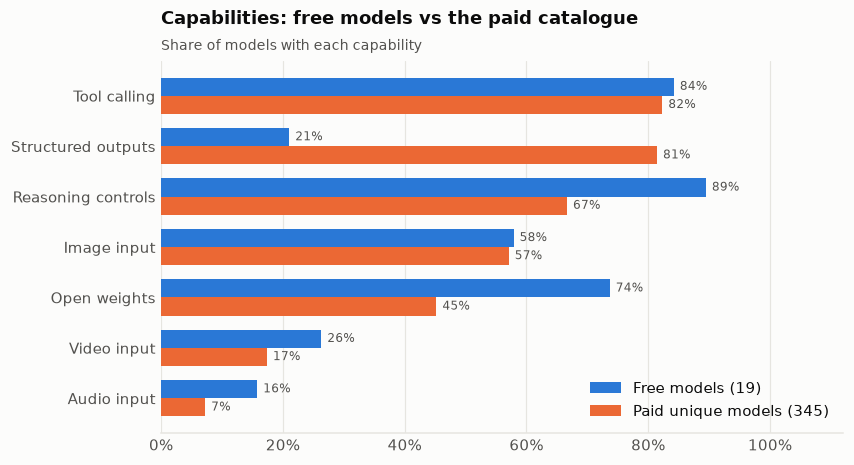

In [12]:
print("Free endpoints by host:")
print(endpoints[endpoints.model_id.isin(free.id)].provider.value_counts().to_string())

caps2 = {"Tool calling": "supports_tools", "Structured outputs": "supports_structured_outputs",
         "Reasoning controls": "supports_reasoning", "Image input": "input_image",
         "Video input": "input_video", "Audio input": "input_audio", "Open weights": "open_weights"}
free["open_weights"] = free.base_id.map(paid_sib.open_weights).fillna(free.open_weights).astype(bool)
comp = pd.DataFrame({"Free models": {k: free[c].mean() * 100 for k, c in caps2.items()},
                     "Paid catalogue": {k: paid[c].mean() * 100 for k, c in caps2.items()}})
comp = comp.sort_values("Paid catalogue")

fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(comp))
h = 0.36
ax.barh(y + h / 2, comp["Free models"], height=h, color=BLUE, label=f"Free models ({len(free)})")
ax.barh(y - h / 2, comp["Paid catalogue"], height=h, color=ORANGE, label=f"Paid unique models ({len(paid)})")
for yy, (a, b) in zip(y, comp.values):
    ax.text(a + 1, yy + h / 2, f"{a:.0f}%", va="center", fontsize=8, color=TEXT_2)
    ax.text(b + 1, yy - h / 2, f"{b:.0f}%", va="center", fontsize=8, color=TEXT_2)
ax.set_yticks(y, comp.index)
ax.set_xlim(0, 112)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.legend(loc="lower right")
viz.title(ax, "Capabilities: free models vs the paid catalogue", "Share of models with each capability")
plt.show()

### 2.3 How long free models last

A single snapshot only shows how long the *current* free models have been listed. Free variants that were withdrawn earlier can't be seen. Measuring how long free models last needs daily snapshots, which is the next step.

In [13]:
free[["id", "created", "days_listed"]].assign(created=lambda d: d.created.dt.date) \
    .sort_values("days_listed", ascending=False).reset_index(drop=True)

,id,created,days_listed
0,nvidia/nemotron-3-super-120b-a12b:free,2026-03-11,202
1,google/lyria-3-pro-preview,2026-03-30,183
2,google/lyria-3-clip-preview,2026-03-30,183
3,google/gemma-4-31b-it:free,2026-04-02,180
4,google/gemma-4-26b-a4b-it:free,2026-04-03,179
5,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free,2026-04-28,154
6,nvidia/nemotron-3-ultra-550b-a55b:free,2026-06-04,117
7,nvidia/nemotron-3.5-content-safety:free,2026-06-04,117
8,cohere/north-mini-code:free,2026-06-17,104
9,poolside/laguna-xs-2.1:free,2026-07-02,89


## 3. Providers

Each model can be served by several providers, each with its own price, quantization (the precision the model runs at), limits and uptime. This section covers unique models only.

### 3.1 How many providers serve each model?

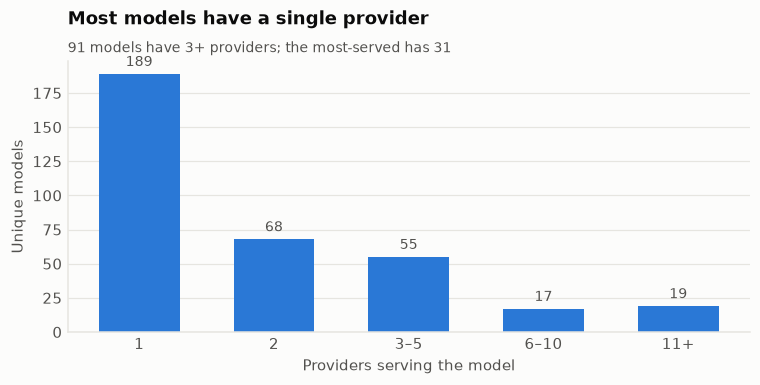

In [14]:
n = ep.groupby("base_id").provider.nunique().reindex(primary.id, fill_value=0)
edges = [-1, 0, 1, 2, 5, 10, np.inf]
names = ["0", "1", "2", "3–5", "6–10", "11+"]
dist = pd.cut(n, edges, labels=names).value_counts().reindex(names)
dist = dist[(dist > 0) | (dist.index != "0")]

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(dist.index, dist.values, width=0.6, color=BLUE)
ax.bar_label(bars, padding=3, color=TEXT_2, fontsize=9)
ax.grid(axis="x", visible=False)
ax.set_xlabel("Providers serving the model")
ax.set_ylabel("Unique models")
viz.title(ax, "Most models have a single provider",
          f"{(n >= 3).sum()} models have 3+ providers; the most-served has {n.max()}")
plt.show()

### 3.2 How much does the price vary for the same model?

For models with 3+ priced providers, this compares each model's cheapest and most expensive offering on blended price. A provider can list several tiers for one model (e.g. `baseten/fast`, `mistral/zdr`, regional endpoints), so each tier counts as its own price point.

91 models with 3+ priced providers. Max/min price ratio: median 2.0x, p90 6.0x, max 22.3x


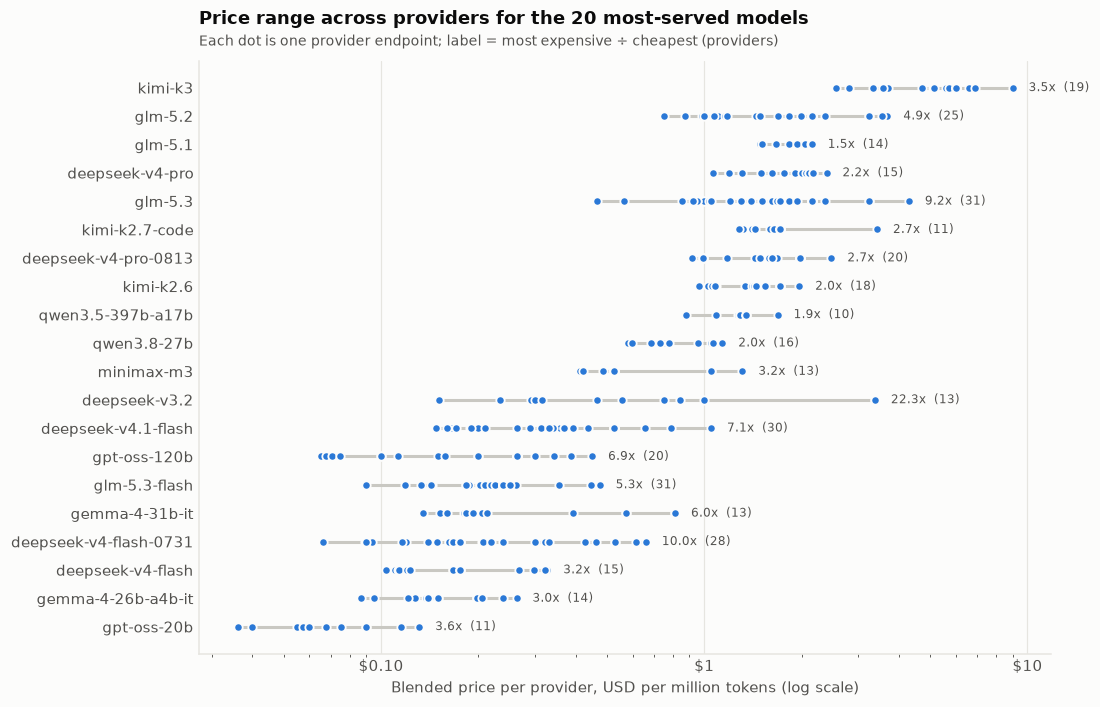

In [15]:
priced = ep[ep.price_blended > 0]
g = priced.groupby("base_id").price_blended
spread = pd.DataFrame({"providers": priced.groupby("base_id").provider.nunique(), "endpoints": g.size(),
                       "min": g.min(), "median": g.median(), "max": g.max()})
spread = spread[spread.providers >= 3]
spread["max_over_min"] = spread["max"] / spread["min"]
print(f"{len(spread)} models with 3+ priced providers. Max/min price ratio: "
      f"median {spread.max_over_min.median():.1f}x, p90 {spread.max_over_min.quantile(0.9):.1f}x, max {spread.max_over_min.max():.1f}x")

top = spread.sort_values("providers", ascending=False).head(20).sort_values("median")
fig, ax = plt.subplots(figsize=(10, 7))
for i, mid in enumerate(top.index):
    pts = priced[priced.base_id == mid].price_blended
    ax.hlines(i, pts.min(), pts.max(), color=NEUTRAL, lw=2, zorder=1)
    ax.scatter(pts, np.full(len(pts), i), s=30, color=BLUE, edgecolor=viz.SURFACE, linewidth=1.2, zorder=3)
    ax.text(pts.max() * 1.12, i, f"{top.loc[mid, 'max_over_min']:.1f}x  ({int(top.loc[mid, 'providers'])})",
            va="center", fontsize=8, color=TEXT_2)
ax.set_yticks(range(len(top)), [m.split("/")[1] for m in top.index])
ax.set_xscale("log")
ax.xaxis.set_major_formatter(usd)
ax.set_xlabel("Blended price per provider, USD per million tokens (log scale)")
ax.grid(axis="y", visible=False)
viz.title(ax, "Price range across providers for the 20 most-served models",
          "Each dot is one provider endpoint; label = most expensive ÷ cheapest (providers)")
plt.show()

### 3.3 Does quantization explain the price differences?

Each endpoint's price is divided by the median price for its model (models with 3+ priced providers), so 1.0 means "typical for this model".

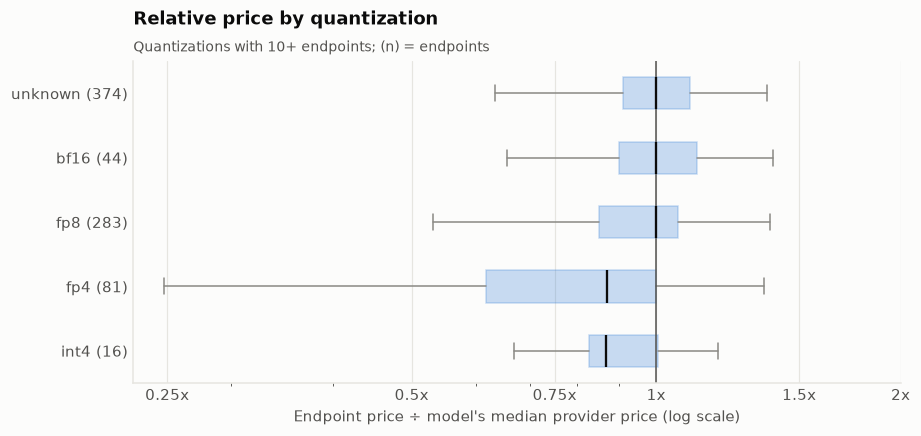

,size,median
quantization,,
int4,16,0.87
fp4,81,0.87
fp8,283,1.00
bf16,44,1.00
unknown,374,1.00


In [16]:
multi = priced[priced.base_id.isin(spread.index)].copy()
multi["rel_price"] = multi.price_blended / multi.base_id.map(spread["median"])
order = multi.groupby("quantization").rel_price.median().sort_values().index
order = [q for q in order if (multi.quantization == q).sum() >= 10]

fig, ax = plt.subplots(figsize=(9, 3.8))
data = [multi.loc[multi.quantization == q, "rel_price"] for q in order]
bp = ax.boxplot(data, orientation="horizontal", widths=0.5, showfliers=False, patch_artist=True,
                medianprops=dict(color=TEXT, lw=1.5), whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED), boxprops=dict(facecolor=BLUE, alpha=0.25, edgecolor=BLUE))
ax.set_yticks(range(1, len(order) + 1), [f"{q} ({(multi.quantization == q).sum()})" for q in order])
ax.axvline(1, color=TEXT_2, lw=1)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 0.75, 1, 1.5, 2])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("Endpoint price ÷ model's median provider price (log scale)")
ax.grid(axis="y", visible=False)
viz.title(ax, "Relative price by quantization", "Quantizations with 10+ endpoints; (n) = endpoints")
plt.show()

multi.groupby("quantization").rel_price.agg(["size", "median"]).loc[order].round(2)

### 3.4 Reliability: uptime over the last day

Uptime is the only reliability measure in the public data. Latency and throughput are blank for every endpoint in this snapshot.

Latency populated for 0 / 1310 endpoints; throughput for 0
Endpoint uptime (last 1d): median 99.79%, 24% below 99%, 8% below 95%


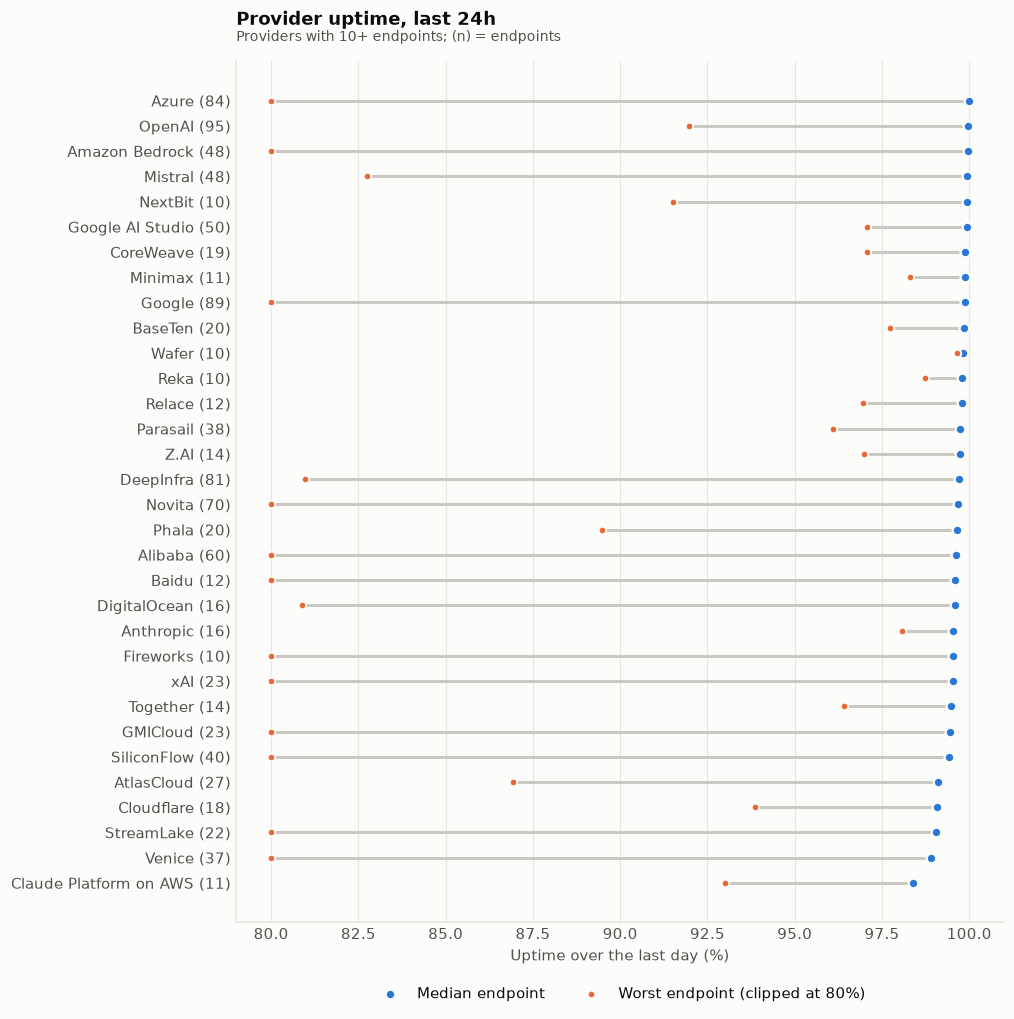

In [17]:
print(f"Latency populated for {ep.latency_30m.notna().sum()} / {len(ep)} endpoints; throughput for {ep.throughput_30m.notna().sum()}")
up = ep.dropna(subset=["uptime_1d"])
print(f"Endpoint uptime (last 1d): median {up.uptime_1d.median():.2f}%, "
      f"{(up.uptime_1d < 99).mean():.0%} below 99%, {(up.uptime_1d < 95).mean():.0%} below 95%")

pu = up.groupby("provider").uptime_1d.agg(["size", "median", "min"])
pu = pu[pu["size"] >= 10].sort_values("median")
fig, ax = plt.subplots(figsize=(9, 0.28 * len(pu) + 1.2))
y = np.arange(len(pu))
ax.hlines(y, pu["min"].clip(lower=80), pu["median"], color=NEUTRAL, lw=2, zorder=1)
ax.scatter(pu["median"], y, s=40, color=BLUE, edgecolor=viz.SURFACE, linewidth=1.5, zorder=3, label="Median endpoint")
ax.scatter(pu["min"].clip(lower=80), y, s=24, color=ORANGE, edgecolor=viz.SURFACE, linewidth=1.2, zorder=3, label="Worst endpoint (clipped at 80%)")
ax.set_yticks(y, [f"{p} ({n})" for p, n in zip(pu.index, pu["size"])])
ax.set_xlabel("Uptime over the last day (%)")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.6 / fig.get_figheight()), ncol=2)
viz.title(ax, "Provider uptime, last 24h", "Providers with 10+ endpoints; (n) = endpoints")
plt.show()

### 3.5 Provider size, location and data retention

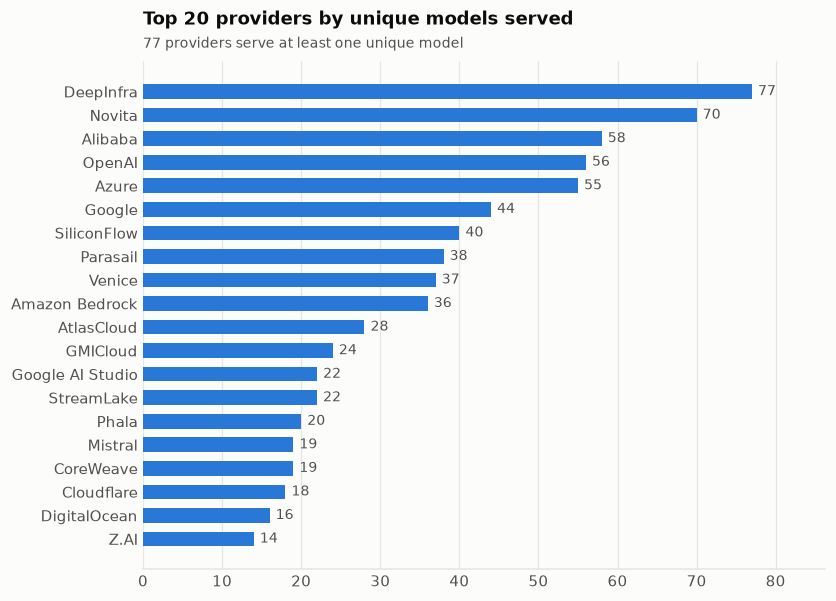

Zero-data-retention endpoints: 64% of 1310; 255 of 348 served models have at least one ZDR provider

Provider headquarters (all listed providers):
headquarters
US            55
not stated    38
SG             6
CN             6
IL             2
ES             1
NL             1
ID             1
SE             1
FR             1


,provider,headquarters,n_models,zdr_share,median_uptime_1d
0,DeepInfra,US,77,1.000,99.713
1,Novita,US,70,1.000,99.687
2,Alibaba,SG,58,0.000,99.633
3,OpenAI,US,56,0.000,99.962
4,Azure,US,55,0.814,99.982
5,Google,US,44,0.938,99.868
6,SiliconFlow,SG,40,1.000,99.433
7,Parasail,US,38,1.000,99.741
8,Venice,US,37,1.000,98.896
9,Amazon Bedrock,US,36,0.828,99.961


In [18]:
# Recompute per-provider stats on unique-model endpoints only (tables.py counts :free/:batch too).
stats = ep.groupby("provider").agg(n_models=("base_id", "nunique"), zdr_share=("zdr", "mean"),
                                   median_uptime_1d=("uptime_1d", "median"))
pv = providers.drop(columns=["n_models", "zdr_share", "median_uptime_1d", "n_endpoints"])     .merge(stats, left_on="provider", right_index=True).sort_values("n_models", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
t20 = pv.head(20)
viz.hbar(ax, t20.provider, t20.n_models)
viz.title(ax, "Top 20 providers by unique models served", f"{len(pv)} providers serve at least one unique model")
plt.show()

print(f"Zero-data-retention endpoints: {ep.zdr.mean():.0%} of {len(ep)}; "
      f"{ep[ep.zdr].base_id.nunique()} of {ep.base_id.nunique()} served models have at least one ZDR provider")
print("\nProvider headquarters (all listed providers):")
print(providers.headquarters.fillna("not stated").value_counts().to_string())
pv[["provider", "headquarters", "n_models", "zdr_share", "median_uptime_1d"]].head(20).round(3).reset_index(drop=True)

## Takeaways

_Written from this snapshot. Re-check after refreshing._

**Catalogue**
- 464 listings reduce to **348 unique models** from 53 publishers, served by 80 providers. 45% have open weights (a Hugging Face link).
- Blended price: **median $0.75 per million tokens**, with 80% between $0.11 and $6. The most expensive model costs $262.50.
- **Open-weight models make up the cheap end of the value frontier**: DeepSeek V4 Flash (score 34 for $0.09), GLM-5.3 Flash (42 for $0.24) and MiMo V2.6 Pro (46 for $0.54). Proprietary models appear only at the top: going from MiMo V2.6 Pro to Claude Opus 5.5 costs about 15× more for about 11 more points.
- New models are arriving faster: 41 unique models were added in September 2026, 32 of them proprietary.
- Tool calling (82%) and JSON output (85%) are close to standard. Audio and image *output* are rare (≤3%).

**Free models**
- 19 free listings. 15 are `:free` variants of paid models, mostly served by their own makers (Nvidia, Google AI Studio, Poolside, Thinking Machines).
- The main catch is **output length**: for 8 of the 11 models with a paid version, the free endpoint allows less output (median 36% of the paid limit). Context windows are usually the same as paid, and sometimes bigger.
- Only **21% of free models support structured outputs, against 81% of paid models**. Tool calling (84%) and reasoning controls (89%) are well supported.
- The oldest current free listing is about 200 days old. Measuring how long free models last needs daily snapshots.

**Providers**
- **54% of models have a single provider.** 91 models have 3 or more.
- For models with 3+ providers, the most expensive offering typically costs **2×** the cheapest (p90 6×, maximum 22× for DeepSeek V3.2).
- Quantization explains some of that: fp4/int4 endpoints are about 13% cheaper than the model's median, while fp8 and bf16 are about the same as the median. Quantization isn't reported for 53% of endpoints.
- Median endpoint uptime over the last day was 99.8%, but 24% of endpoints were below 99%. Latency and throughput are not in the public data.
- 64% of endpoints are zero-data-retention, and 255 of 348 models have at least one ZDR provider. The model makers' own endpoints (OpenAI, Anthropic, Google AI Studio, Alibaba) are not ZDR.

**Next steps:** run `fetch.py` daily to track price changes, new models and how long free models last. Add an API key to measure the free models' speed ourselves.